<a href="https://colab.research.google.com/github/hotsard/2026_bigdata_computing_class/blob/main/%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  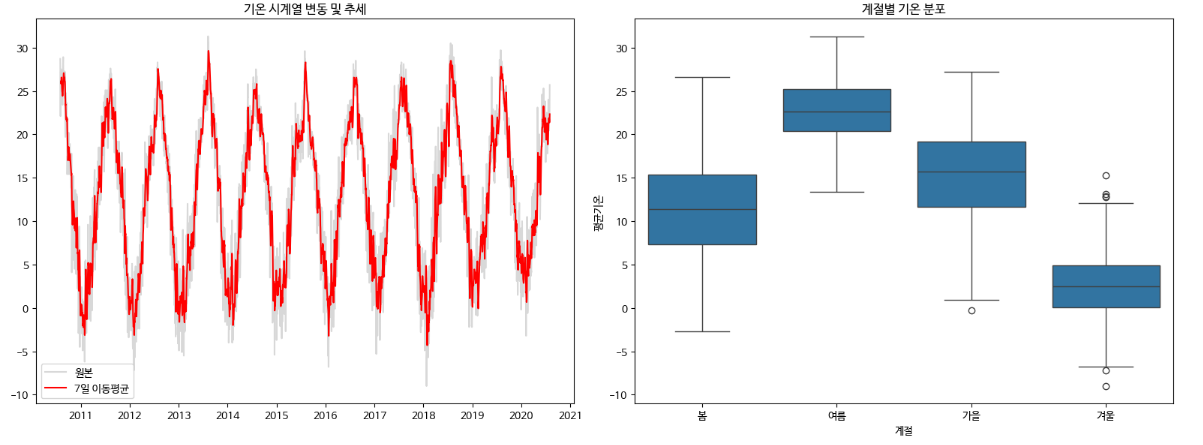

  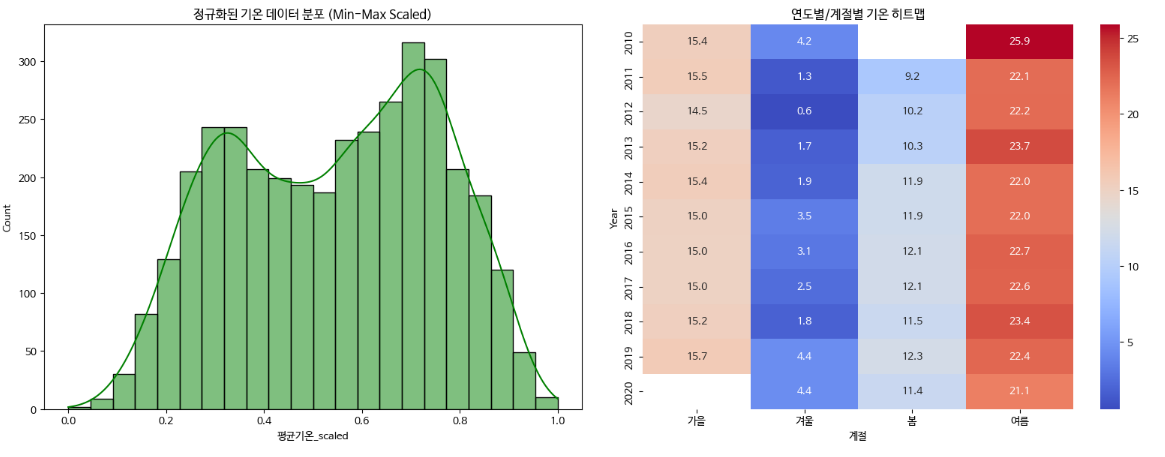



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import warnings
import os

warnings.filterwarnings('ignore')
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
if not os.path.exists(font_path):
    !sudo apt-get install -y fonts-nanum > /dev/null
font_prop = fm.FontProperties(fname=font_path)


cal_df =pd.read_csv("weather.csv",encoding = 'CP949')


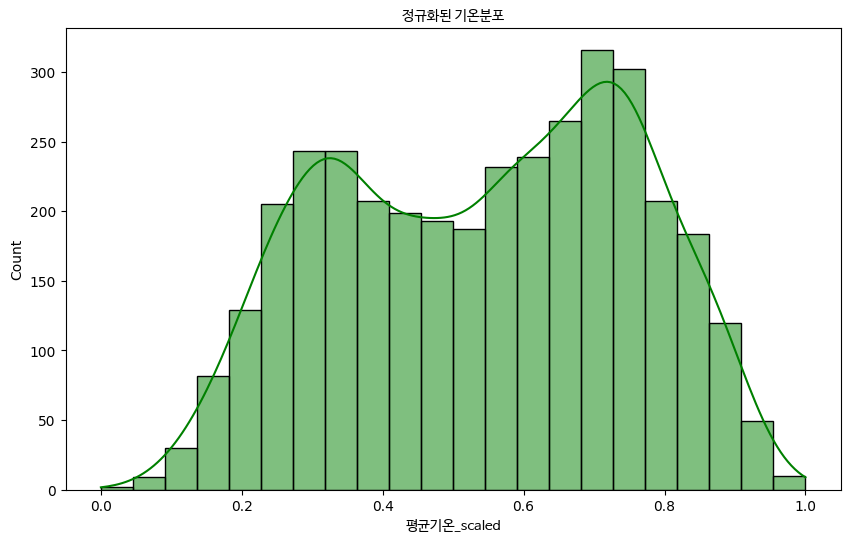

In [ ]:
#정규화된 기온 분포 그래프
df2 = cal_df['평균기온']

#0-1사이의 범위로 변환 (최소값 -> 0, 최대값 -> 1)
def min_max_scale(series):
  result = (series -series.min()) / (series.max()-series.min())
  return result

temp = pd.DataFrame(min_max_scale(df2))

plt.figure(figsize=(10,6))
sns.histplot(data = temp,x = '평균기온',bins =22,kde = True,color= 'green',edgecolor = 'black')

plt.title('정규화된 기온분포',fontproperties = font_prop)
plt.xlabel('평균기온_scaled',fontproperties = font_prop)
plt.ylabel('Count')
plt.show()

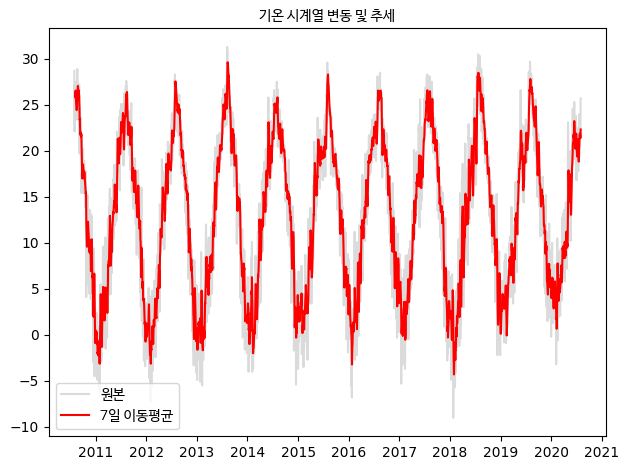

In [ ]:
#기온 시계별 변동 및 추세
cal_df['일시'] = pd.to_datetime(cal_df['일시'])
ts_df = cal_df.set_index('일시')['평균기온']

avg_temp = ts_df.rolling(window =7).mean()

plt.plot(ts_df.index, ts_df.values,
         color='lightgray', label='원본',alpha=0.8 )

plt.plot(avg_temp.index, avg_temp.values,
         color='red', label='7일 이동평균')


plt.title('기온 시계열 변동 및 추세',fontproperties = font_prop)
plt.legend(loc='lower left',prop = font_prop)


plt.tight_layout()
plt.show()

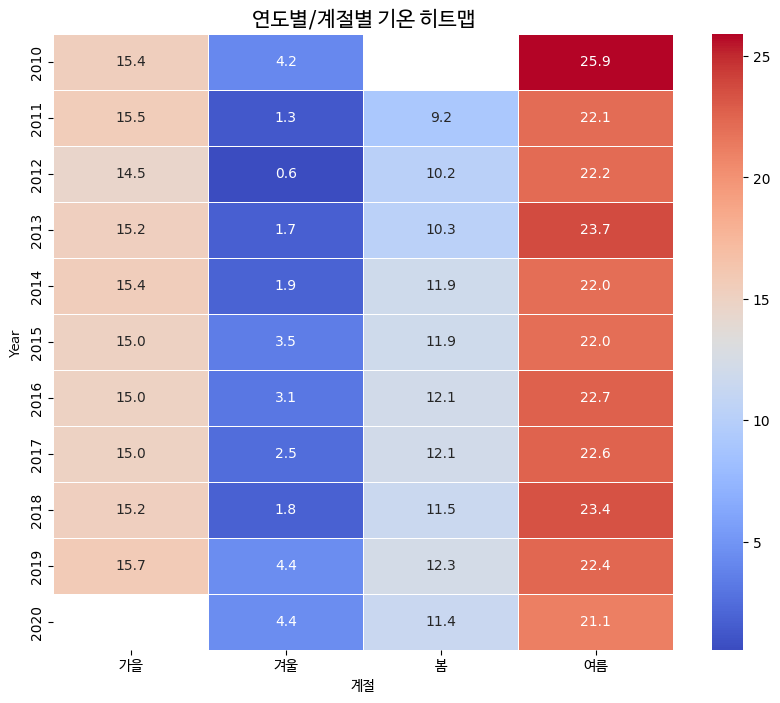

In [ ]:
cal_df_year = cal_df['일시'].dt.year
cal_df_month = cal_df['일시'].dt.month

def get_season(month):
    if month in [3, 4, 5]: return '봄'
    elif month in [6, 7, 8]: return '여름'
    elif month in [9, 10, 11]: return '가을'
    else: return '겨울'

cal_df_season= cal_df_month.apply(get_season)


heatmap_data = cal_df.pivot_table(index=cal_df_year, columns=cal_df_season, values='평균기온', aggfunc='mean')
plt.figure(figsize=(10, 8))

sns.heatmap(heatmap_data, annot=True,fmt=".1f",cmap='coolwarm',linewidths=.5)

# 폰트 적용 (이미 설정한 font_prop 활용)
plt.title('연도별/계절별 기온 히트맵', fontproperties=font_prop, fontsize=15)
plt.xlabel('계절', fontproperties=font_prop)
plt.ylabel('Year', fontproperties=font_prop)

# x축 라벨(계절 이름)에도 폰트 적용
plt.xticks(fontproperties=font_prop)

plt.show()


In [ ]:
season_order = ['봄', '여름', '가을', '겨울']

sns.boxplot(data=cal_df, x=season_order, y= df2,
            order=season_order,
            color='Blue')


plt.title('계절별 기온 분포', fontproperties=font_prop, fontsize=15)
plt.xlabel('계절', fontproperties=font_prop)
plt.ylabel('평균기온', fontproperties=font_prop)
plt.xticks(fontproperties=font_prop)

plt.show()

ValueError: Length of list vectors must match length of `data` when both are used, but `data` has length 3653 and the vector passed to `x` has length 4.

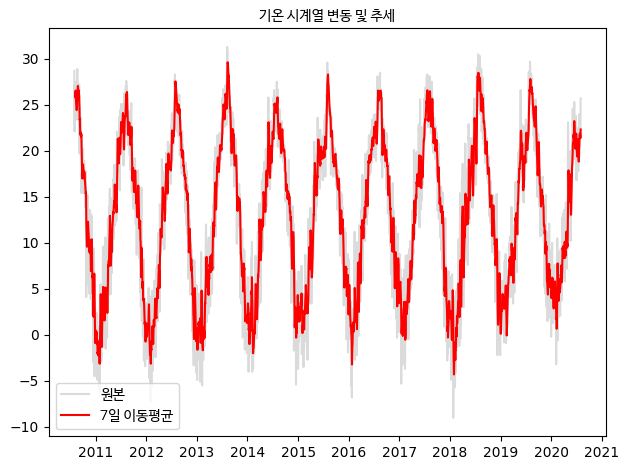

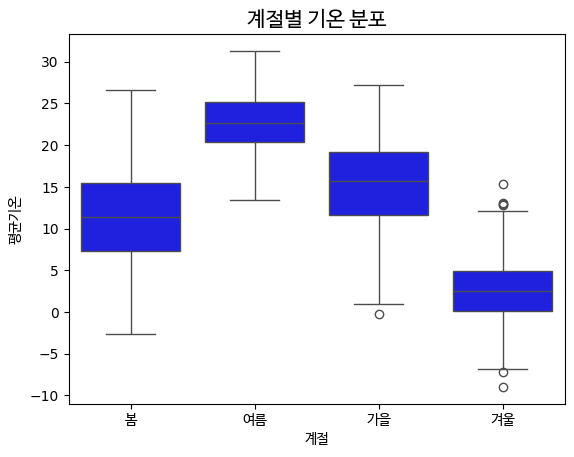

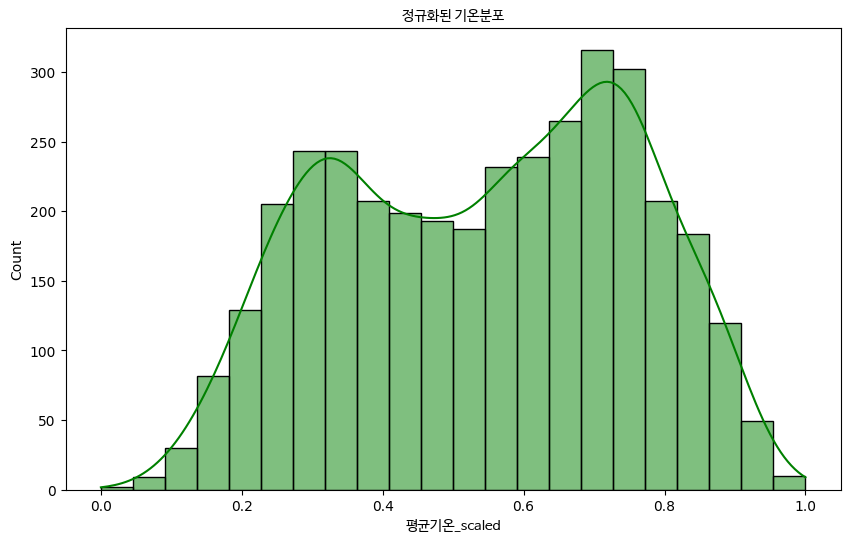

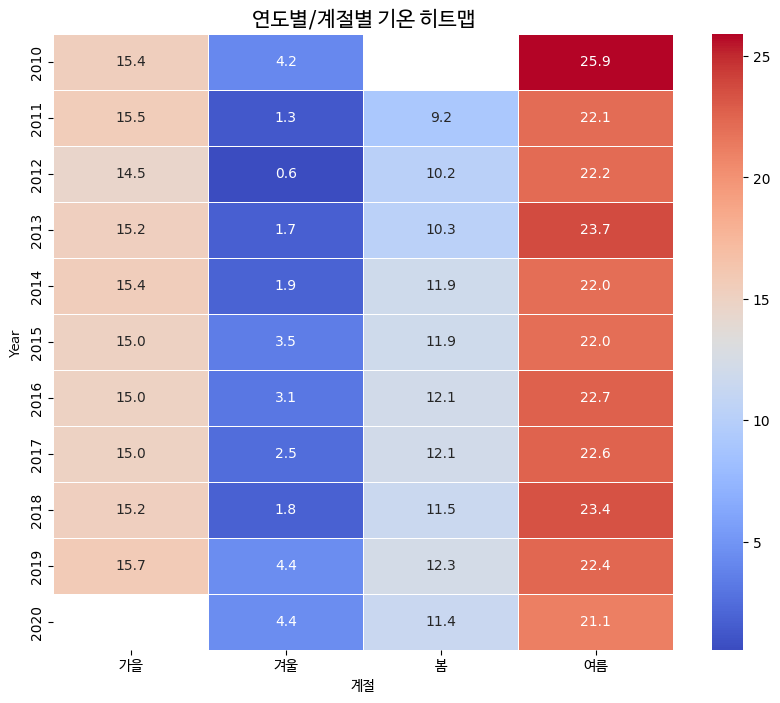

엑셀 파일 저장 완료: weather_analysis_report.xlsx


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import warnings
import os

warnings.filterwarnings('ignore')
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
if not os.path.exists(font_path):
    !sudo apt-get install -y fonts-nanum > /dev/null
font_prop = fm.FontProperties(fname=font_path)


cal_df =pd.read_csv("weather.csv",encoding = 'CP949')


#기온 시계별 변동 및 추세
cal_df['일시'] = pd.to_datetime(cal_df['일시'])
ts_df = cal_df.set_index('일시')['평균기온']

avg_temp = ts_df.rolling(window =7).mean()

plt.plot(ts_df.index, ts_df.values,color='lightgray', label='원본',alpha=0.8 )

plt.plot(avg_temp.index, avg_temp.values,
         color='red', label='7일 이동평균')


plt.title('기온 시계열 변동 및 추세',fontproperties = font_prop)
plt.legend(loc='lower left',prop = font_prop)


plt.tight_layout()
plt.show()

cal_df_month = cal_df['일시'].dt.month
cal_df['계절'] = cal_df_month.apply(get_season)
season_order = ['봄', '여름', '가을', '겨울']
sns.boxplot(data=cal_df, x= '계절', y= '평균기온', order=season_order,color='Blue')


plt.title('계절별 기온 분포', fontproperties=font_prop, fontsize=15)
plt.xlabel('계절', fontproperties=font_prop)
plt.ylabel('평균기온', fontproperties=font_prop)
plt.xticks(fontproperties=font_prop)
plt.show()

#정규화된 기온 분포 그래프
df2 = cal_df['평균기온']

#0-1사이의 범위로 변환 (최소값 -> 0, 최대값 -> 1)
def min_max_scale(series):
  result = (series -series.min()) / (series.max()-series.min())
  return result

temp = pd.DataFrame(min_max_scale(df2))

plt.figure(figsize=(10,6))
sns.histplot(data = temp,x = '평균기온',bins =22,kde = True,color= 'green',edgecolor = 'black')

plt.title('정규화된 기온분포',fontproperties = font_prop)
plt.xlabel('평균기온_scaled',fontproperties = font_prop)
plt.ylabel('Count')
plt.show()


cal_df_year = cal_df['일시'].dt.year
cal_df_month = cal_df['일시'].dt.month

def get_season(month):
    if month in [3, 4, 5]: return '봄'
    elif month in [6, 7, 8]: return '여름'
    elif month in [9, 10, 11]: return '가을'
    else: return '겨울'

cal_df_season= cal_df_month.apply(get_season)


heatmap_data = cal_df.pivot_table(index=cal_df_year, columns=cal_df_season, values='평균기온', aggfunc='mean')
plt.figure(figsize=(10, 8))

sns.heatmap(heatmap_data, annot=True,fmt=".1f",cmap='coolwarm',linewidths=.5)

# 폰트 적용 (이미 설정한 font_prop 활용)
plt.title('연도별/계절별 기온 히트맵', fontproperties=font_prop, fontsize=15)
plt.xlabel('계절', fontproperties=font_prop)
plt.ylabel('Year', fontproperties=font_prop)

# x축 라벨(계절 이름)에도 폰트 적용
plt.xticks(fontproperties=font_prop)

plt.show()



season_order = ['봄', '여름', '가을', '겨울']
season_stats = cal_df.groupby('계절')['평균기온'].describe().reindex(season_order)


with pd.ExcelWriter("weather_analysis_report.xlsx") as f:

    cal_df.to_excel(f, sheet_name='전처리 데이터', index=False)

    season_stats.to_excel(f, sheet_name='계절별 통계', index=True)

    heatmap_data.to_excel(f, sheet_name='연도별 피벗 테이블', index=True)

print("엑셀 파일 저장 완료: weather_analysis_report.xlsx")